# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv("/content/hotel_bookings_raw.csv")
df.head(100)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0.0,0.0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0.0,0.0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0.0,0.0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0.0,0.0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0.0,1.0,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Resort Hotel,1,72,2015,July,27,3,0,2,2,...,No Deposit,240.0,NaN,0,Transient,73.80,0.0,1.0,Canceled,2015-06-29
96,Resort Hotel,1,63,2015,July,27,3,2,5,2,...,No Deposit,242.0,NaN,0,Transient,117.00,0.0,1.0,Canceled,2015-05-13
97,Resort Hotel,0,63,2015,July,27,3,2,5,3,...,No Deposit,105.0,NaN,0,Transient,196.54,0.0,1.0,Check-Out,2015-07-10
98,Resort Hotel,0,101,2015,July,27,3,2,5,2,...,No Deposit,240.0,NaN,0,Transient,99.30,1.0,2.0,Check-Out,2015-07-10


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.shape

(51390, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51390 entries, 0 to 51389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           51390 non-null  object 
 1   is_canceled                     51390 non-null  int64  
 2   lead_time                       51390 non-null  int64  
 3   arrival_date_year               51390 non-null  int64  
 4   arrival_date_month              51390 non-null  object 
 5   arrival_date_week_number        51390 non-null  int64  
 6   arrival_date_day_of_month       51390 non-null  int64  
 7   stays_in_weekend_nights         51390 non-null  int64  
 8   stays_in_week_nights            51390 non-null  int64  
 9   adults                          51390 non-null  int64  
 10  children                        51386 non-null  float64
 11  babies                          51390 non-null  int64  
 12  meal                            

In [5]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [6]:
df.duplicated().sum()

np.int64(11031)

In [7]:
df["is_canceled"].value_counts()

,count
is_canceled,
0,34209
1,17181


<Axes: >

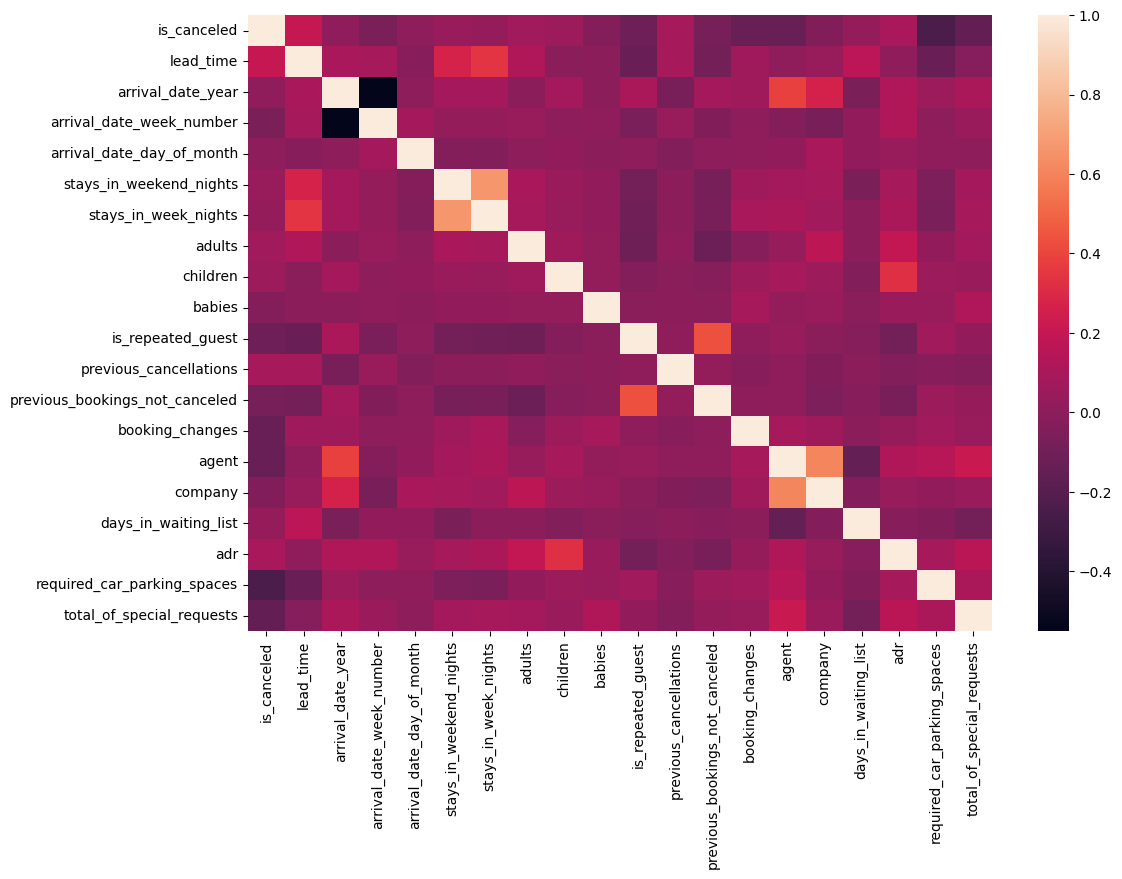

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr()
)

Berdasarkan eksplorasi data awal, dataset hotel booking ini terdiri dari **119.390** baris dengan **32** kolom. Tipe data yang digunakan cukup beragam, yaitu **4 kolom bertipe float**, **16 kolom bertipe integer**, dan **12 kolom bertipe object**. Analisis kualitas data menunjukkan adanya **missing value** pada beberapa kolom: **country sebanyak 488**, **agent sebanyak 16.340**, serta **company yang paling dominan dengan 112.593** nilai kosong. **Kolom company perlu dihapus** karena proporsi missing value yang sangat besar dapat mengganggu proses pembersihan. Selain itu, ditemukan **31.994 baris duplikat** yang harus dihilangkan agar model tidak bias. Distribusi **label is_canceled menunjukkan ketidakseimbangan moderat**, dengan **75.166 data tidak dibatalkan** dan **44.224 data dibatalkan**.

Hasil analisis korelasi memperlihatkan beberapa hubungan penting. Label is_canceled memiliki korelasi kuat dengan lead_time, serta berkebalikan dengan required_car_parking_spaces dan total_of_special_requests, yang menunjukkan bahwa **semakin banyak permintaan khusus, semakin kecil kemungkinan pembatalan**. Di sisi lain, terdapat korelasi antar fitur yang cukup erat, seperti arrival_date_year yang berkebalikan dengan arrival_date_week_number, serta stays_in_weekend_nights yang berkaitan dengan stays_in_week_nights. Fitur adults berkaitan dengan adr, namun berkebalikan dengan is_repeated_guest dan previous_bookings_not_canceled. Hubungan serupa juga terlihat pada children dengan adr, serta is_repeated_guest dengan previous_bookings_not_canceled. Selain itu, previous_bookings_not_canceled berkaitan dengan previous_cancellations.

Secara keseluruhan, EDA ini memberikan gambaran bahwa fitur lead_time, special_requests, serta beberapa variabel terkait **tamu dan lama menginap memiliki pengaruh besar terhadap pembatalan pemesanan**. Temuan ini menjadi dasar penting untuk tahap pembersihan data, feature engineering, dan pemodelan selanjutnya.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [9]:
drop_cols = [
    "company",
    "agent"
]

df.drop(
    columns=drop_cols,
    inplace=True
)

print(f"Jumlah kolom saat ini: {df.shape[1]} kolom")

Jumlah kolom saat ini: 30 kolom


In [10]:
df.dropna(
    inplace=True
)

print(f"Jumlah baris data saat ini: {df.shape[0]} baris")

Jumlah baris data saat ini: 50907 baris


In [11]:
df.drop_duplicates(inplace=True)

print(f"Jumlah baris data saat ini setelah menghapus duplikat: {df.shape[0]} baris")

Jumlah baris data saat ini setelah menghapus duplikat: 39895 baris


In [12]:
for col in df.select_dtypes(include='object'):

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col]
    )

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0,342,2015,5,27,1,0,0,2,...,2,3,0,0,2,0.0,0.0,0.0,1,116
1,1,0,737,2015,5,27,1,0,0,2,...,2,4,0,0,2,0.0,0.0,0.0,1,116
2,1,0,7,2015,5,27,1,0,1,1,...,2,0,0,0,2,75.0,0.0,0.0,1,117
3,1,0,13,2015,5,27,1,0,1,1,...,0,0,0,0,2,75.0,0.0,0.0,1,117
4,1,0,14,2015,5,27,1,0,2,2,...,0,0,0,0,2,98.0,0.0,1.0,1,118


In [13]:
df.to_csv(
    "hotel_bookings_preprocessing.csv",
    index=False
)

print(f"Data hasil preprocessing berhasil dibuat.")

Data hasil preprocessing berhasil dibuat.
